## Evaluation of RobotAgent versions on different mission layouts

In [ ]:
# GROUP : 23
# DATE : 28.03.2025
# MEMBERS :
# - ZUO Yuxian
# - NADALIN	Marius
# - EL BARHICHI	Mohammed

### Imports & setup

In [2]:
from tqdm import tqdm
import sys
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append('./MAS')

from MAS.model import RobotMission

In [5]:
def run_model(model, max_steps):
    """
    Run the model once and return the score (Nb. steps to clean).
    """
    model.reset()
    nb_steps = 0
    terminated = False
    
    while not terminated:
        if nb_steps > max_steps:
            break
        model.step()
        nb_steps += 1
        terminated = model.is_mission_terminated()
    
    return nb_steps, terminated

def evaluate_model(model, N, max_steps, df=None):
    """
    Evaluate the model N times and return the average score (Nb. steps to clean).
    """
    avg_score = 0
    nb_terminated = 0
    
    for _ in tqdm(range(N)):
        score, terminated = run_model(model, max_steps)
        if terminated:
            avg_score += score
            nb_terminated += 1
        if df is not None:
            df.loc[len(df)] = [score, terminated, model.get_nb_sent_msgs_comm_1(), model.get_nb_sent_msgs_comm_2()]
        
    return avg_score / nb_terminated, nb_terminated / N

def show_results(df):
    """
    Show the results of the evaluation.
    """
    print("Average nb_steps (Nb. steps to clean):", f"{df['nb_steps'].mean():.2f}")
    print("Maximum nb_steps (Nb. steps to clean):",f"{ df['nb_steps'].max():.2f}")
    print("Minimum nb_steps (Nb. steps to clean):", f"{df['nb_steps'].min():.2f}")
    print("Percentage of terminated missions:", f"{df['terminated'].mean() * 100:.2f}", "%")
    print("Average number of messages sent by comm_1:", f"{df['nb_sent_msgs_comm_1'].mean():.2f}")
    print("Average number of messages sent by comm_2:", f"{df['nb_sent_msgs_comm_2'].mean():.2f}")
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    
    # Boxplot
    df['nb_steps'].plot(kind='box', title='Boxplot of Scores', ax=axes[0])
    
    # Histogram
    df['nb_steps'].plot(kind='hist', bins=50, title='Distribution of Scores', ax=axes[1])
    axes[1].set_xlabel('Number of Steps')
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    

In [7]:
N = 1000
max_steps = 1000

### **Robots without communication** - Before applying "dropping after N steps"

In [ ]:
# Model stardard size (12x8) w. 6 robots (G:2 - Y:2 - R:2)
#                               12 wastes (G:6 - Y:3 - R:3)

df_model_1_no_comm_no_drop = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_1_no_comm_no_drop = RobotMission(robot_type="No communication",
                      nb_green_robots=2,
                      nb_yellow_robots=2,
                      nb_red_robots=2,
                      nb_green_wastes=6,
                      nb_yellow_wastes=3,
                      nb_red_wastes=3,
                      width=12,
                      height=8)

avg_score, avg_terminated = evaluate_model(model_1_no_comm_no_drop, N, max_steps, df_model_1_no_comm_no_drop)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

100%|██████████| 100/100 [00:16<00:00,  6.07it/s]

Average Score : 59.03 steps
Average termination of mission : 36.00%


In [ ]:
df_model_1_no_comm_no_drop.to_csv('model_1_no_comm_no_drop.csv', index=False)

In [ ]:
# Model stardard size (12x8) w. 3 robots (G:1 - Y:1 - R:1)
#                               12 wastes (G:6 - Y:3 - R:3)

df_model_2_no_comm_no_drop = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_2_no_comm_no_drop = RobotMission(robot_type="No communication",
                      nb_green_robots=1,
                      nb_yellow_robots=1,
                      nb_red_robots=1,
                      nb_green_wastes=6,
                      nb_yellow_wastes=3,
                      nb_red_wastes=3,
                      width=12,
                      height=8)

avg_score, avg_terminated = evaluate_model(model_2_no_comm_no_drop, N, max_steps, df_model_2_no_comm_no_drop)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

100%|██████████| 100/100 [00:01<00:00, 79.96it/s]

Average Score : 101.15 steps
Average termination of mission : 100.00%


In [ ]:
df_model_2_no_comm_no_drop.to_csv('model_2_no_comm_no_drop.csv', index=False)

In [ ]:
# Model large size (24x16) w. 12 robots (G:4 - Y:4 - R:4)
#                              22 wastes (G:10 - Y:7 - R:5)

df_model_3_no_comm_no_drop = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_3_no_comm_no_drop = RobotMission(robot_type="No communication",
                      nb_green_robots=4,
                      nb_yellow_robots=4,
                      nb_red_robots=4,
                      nb_green_wastes=10,
                      nb_yellow_wastes=7,
                      nb_red_wastes=5,
                      width=24,
                      height=16)

avg_score, avg_terminated = evaluate_model(model_3_no_comm_no_drop, N, max_steps, df_model_3_no_comm_no_drop)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

100%|██████████| 100/100 [01:15<00:00,  1.32it/s]

Average Score : 153.00 steps
Average termination of mission : 6.00%


In [ ]:
df_model_3_no_comm_no_drop.to_csv('model_3_no_comm_no_drop.csv', index=False)

### **Robots without communication** - After applying "dropping after N steps"

In [4]:
# Model stardard size (12x8) w. 6 robots (G:2 - Y:2 - R:2)
#                               12 wastes (G:6 - Y:3 - R:3)

df_model_1_no_comm = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_no_comm_1 = RobotMission(robot_type="No communication",
                      nb_green_robots=2,
                      nb_yellow_robots=2,
                      nb_red_robots=2,
                      nb_green_wastes=6,
                      nb_yellow_wastes=3,
                      nb_red_wastes=3,
                      width=12,
                      height=8)

avg_score, avg_terminated = evaluate_model(model_no_comm_1, N, max_steps, df_model_1_no_comm)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [01:57<00:00,  8.54it/s]

Average Score : 85.04 steps
Average termination of mission : 61.20%


Average nb_steps (Nb. steps to clean): 440.43
Maximum nb_steps (Nb. steps to clean): 1001.00
Minimum nb_steps (Nb. steps to clean): 32.00
Percentage of terminated missions: 61.20 %
Average number of messages sent by comm_1: 0.00
Average number of messages sent by comm_2: 0.00


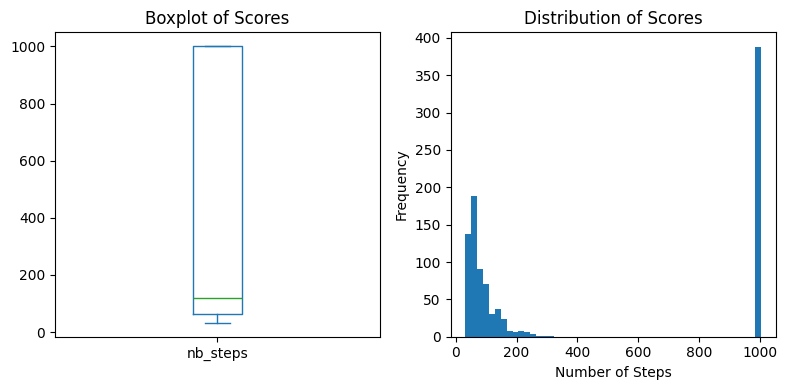

In [25]:
show_results(df_model_1_no_comm)
df_model_1_no_comm.to_csv('model_1_no_comm_no_drop.csv', index=False)

In [6]:
# Model stardard size (12x8) w. 3 robots (G:1 - Y:1 - R:1)
#                               12 wastes (G:6 - Y:3 - R:3)

df_model_2_no_comm = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_no_comm_2 = RobotMission(robot_type="No communication",
                      nb_green_robots=1,
                      nb_yellow_robots=1,
                      nb_red_robots=1,
                      nb_green_wastes=6,
                      nb_yellow_wastes=3,
                      nb_red_wastes=3,
                      width=12,
                      height=8)

avg_score, avg_terminated = evaluate_model(model_no_comm_2, N, max_steps, df_model_2_no_comm)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

100%|██████████| 1000/1000 [00:15<00:00, 65.82it/s]

Average Score : 101.37 steps
Average termination of mission : 100.00%


Average nb_steps (Nb. steps to clean): 101.37
Maximum nb_steps (Nb. steps to clean): 226.00
Minimum nb_steps (Nb. steps to clean): 52.00
Percentage of terminated missions: 100.00 %
Average number of messages sent by comm_1: 0.00
Average number of messages sent by comm_2: 0.00


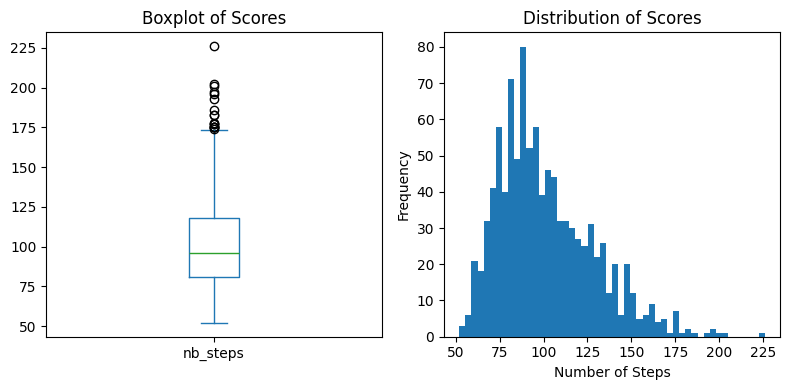

In [26]:
show_results(df_model_2_no_comm)
df_model_2_no_comm.to_csv('model_2_no_comm_no_drop.csv', index=False)

In [ ]:
# Model large size (24x16) w. 12 robots (G:4 - Y:4 - R:4)
#                               22 wastes (G:10 - Y:7 - R:5)

df_model_3_no_comm = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_no_comm_3 = RobotMission(robot_type="No communication",
                      nb_green_robots=4,
                      nb_yellow_robots=4,
                      nb_red_robots=4,
                      nb_green_wastes=10,
                      nb_yellow_wastes=7,
                      nb_red_wastes=5,
                      width=24,
                      height=16)

avg_score, avg_terminated = evaluate_model(model_no_comm_3, N, max_steps, df_model_3_no_comm)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

100%|██████████| 1000/1000 [12:04<00:00,  1.38it/s]

Average Score : 351.23 steps
Average termination of mission : 16.30%


Average nb_steps (Nb. steps to clean): 895.09
Maximum nb_steps (Nb. steps to clean): 1001.00
Minimum nb_steps (Nb. steps to clean): 89.00
Percentage of terminated missions: 16.30 %
Average number of messages sent by comm_1: 0.00
Average number of messages sent by comm_2: 0.00


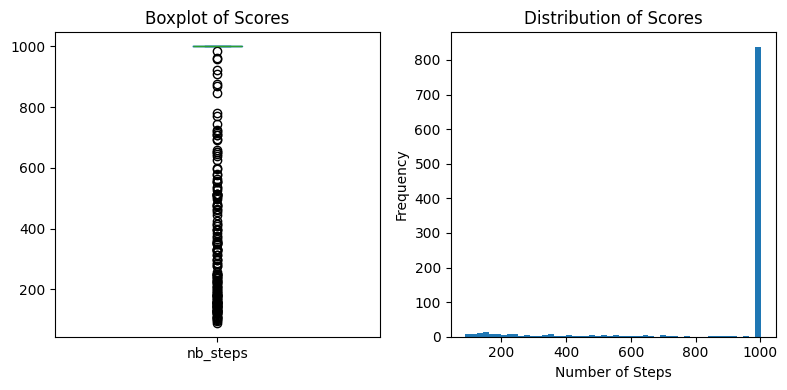

In [27]:
show_results(df_model_3_no_comm)
df_model_3_no_comm.to_csv('model_3_no_comm_no_drop.csv', index=False)

### **Robots with communication** - Using only the first communication (comm1)

In [10]:
# Model stardard size (12x8) w. 6 robots (G:2 - Y:2 - R:2)
#                               12 wastes (G:6 - Y:3 - R:3)

df_model_1_comm = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_with_comm_1 = RobotMission(robot_type="With communication",
                      nb_green_robots=2,
                      nb_yellow_robots=2,
                      nb_red_robots=2,
                      nb_green_wastes=6,
                      nb_yellow_wastes=3,
                      nb_red_wastes=3,
                      width=12,
                      height=8)

avg_score, avg_terminated = evaluate_model(model_with_comm_1, N, max_steps, df_model_1_comm)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

100%|██████████| 1000/1000 [00:18<00:00, 55.48it/s]

Average Score : 67.16 steps
Average termination of mission : 100.00%


Average nb_steps (Nb. steps to clean): 67.16
Maximum nb_steps (Nb. steps to clean): 132.00
Minimum nb_steps (Nb. steps to clean): 35.00
Percentage of terminated missions: 100.00 %
Average number of messages sent by comm_1: 21.89
Average number of messages sent by comm_2: 0.00


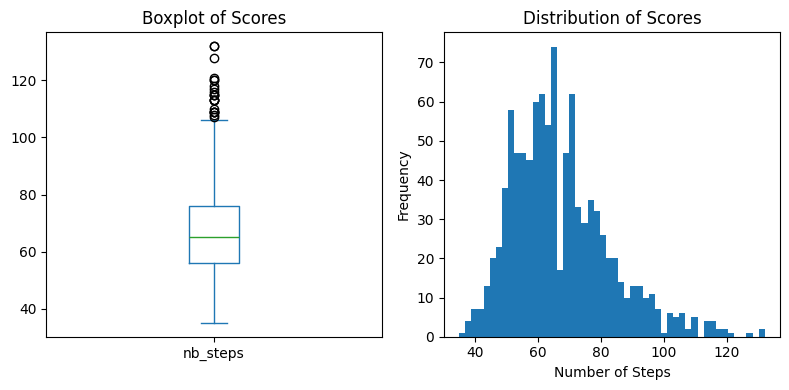

In [28]:
show_results(df_model_1_comm)
df_model_1_comm.to_csv('model_1_comm_1_only.csv', index=False)

In [12]:
# Model stardard size (12x8) w. 3 robots (G:1 - Y:1 - R:1)
#                               12 wastes (G:6 - Y:3 - R:3)

df_model_2_comm = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_with_comm_2 = RobotMission(robot_type="With communication",
                      nb_green_robots=1,
                      nb_yellow_robots=1,
                      nb_red_robots=1,
                      nb_green_wastes=6,
                      nb_yellow_wastes=3,
                      nb_red_wastes=3,
                      width=12,
                      height=8)

avg_score, avg_terminated = evaluate_model(model_with_comm_2, N, max_steps, df_model_2_comm)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

100%|██████████| 1000/1000 [00:16<00:00, 60.11it/s]

Average Score : 99.41 steps
Average termination of mission : 100.00%


Average nb_steps (Nb. steps to clean): 99.41
Maximum nb_steps (Nb. steps to clean): 205.00
Minimum nb_steps (Nb. steps to clean): 50.00
Percentage of terminated missions: 100.00 %
Average number of messages sent by comm_1: 0.00
Average number of messages sent by comm_2: 0.00


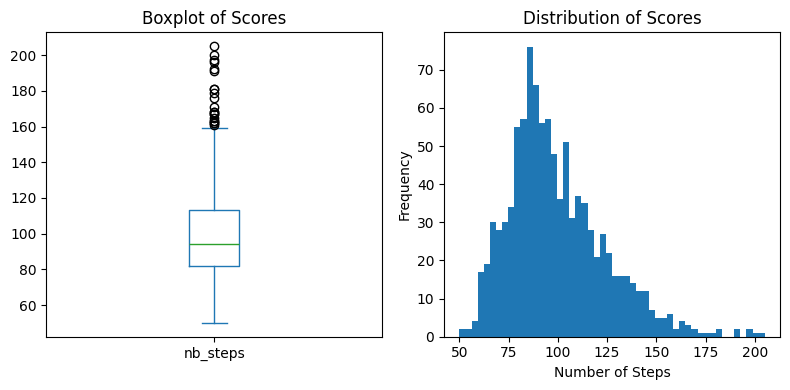

In [29]:
show_results(df_model_2_comm)
df_model_2_comm.to_csv('model_2_comm_1_only.csv', index=False)

In [14]:
# Model large size (24x16) w. 12 robots (G:4 - Y:4 - R:4)

df_model_3_comm = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_with_comm_3 = RobotMission(robot_type="With communication",
                      nb_green_robots=4,
                      nb_yellow_robots=4,
                      nb_red_robots=4,
                      nb_green_wastes=10,
                      nb_yellow_wastes=7,
                      nb_red_wastes=5,
                      width=24,
                      height=16)

avg_score, avg_terminated = evaluate_model(model_with_comm_3, N, max_steps, df_model_3_comm)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

100%|██████████| 1000/1000 [01:58<00:00,  8.42it/s]

Average Score : 164.70 steps
Average termination of mission : 100.00%


Average nb_steps (Nb. steps to clean): 164.70
Maximum nb_steps (Nb. steps to clean): 363.00
Minimum nb_steps (Nb. steps to clean): 86.00
Percentage of terminated missions: 100.00 %
Average number of messages sent by comm_1: 131.49
Average number of messages sent by comm_2: 0.00


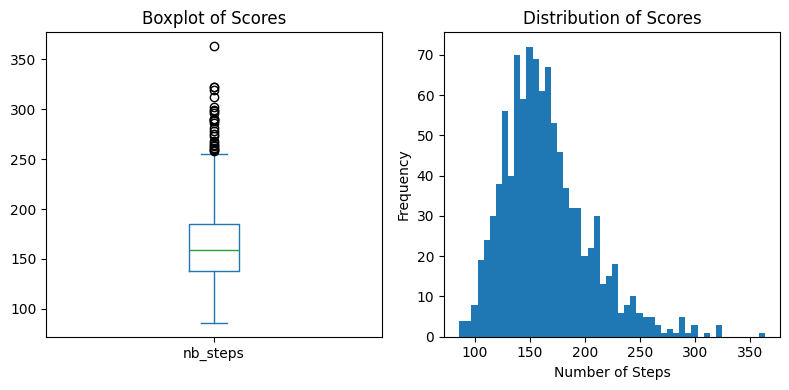

In [30]:
show_results(df_model_3_comm)
df_model_3_comm.to_csv('model_3_comm_1_only.csv', index=False)

### **Robots with communication** - Using both the first and the second communication (comm1 and comm2)

In [8]:
# Model stardard size (12x8) w. 6 robots (G:2 - Y:2 - R:2)
#                               12 wastes (G:6 - Y:3 - R:3)

df_model_1_comm_2= pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_with_comm_2 = RobotMission(robot_type="With communication",
                      nb_green_robots=2,
                      nb_yellow_robots=2,
                      nb_red_robots=2,
                      nb_green_wastes=6,
                      nb_yellow_wastes=3,
                      nb_red_wastes=3,
                      width=12,
                      height=8)

avg_score, avg_terminated = evaluate_model(model_with_comm_2, N, max_steps, df_model_1_comm_2)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:45<00:00, 22.17it/s]

Average Score : 53.75 steps
Average termination of mission : 100.00%


Average nb_steps (Nb. steps to clean): 53.75
Maximum nb_steps (Nb. steps to clean): 84.00
Minimum nb_steps (Nb. steps to clean): 34.00
Percentage of terminated missions: 100.00 %
Average number of messages sent by comm_1: 21.39
Average number of messages sent by comm_2: 12.00


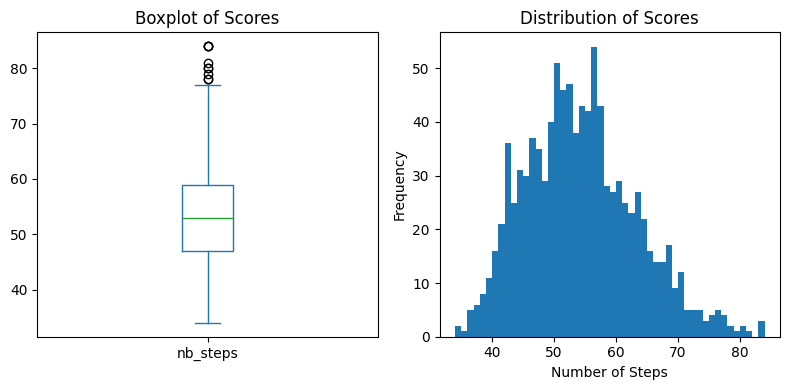

In [9]:
show_results(df_model_1_comm_2)
df_model_1_comm_2.to_csv('model_1_comm_1_and_comm_2.csv', index=False)

In [10]:
# Model stardard size (12x8) w. 3 robots (G:1 - Y:1 - R:1)
#                               12 wastes (G:6 - Y:3 - R:3)

df_model_2_comm_2 = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_2_with_comm_2 = RobotMission(robot_type="With communication",
                      nb_green_robots=1,
                      nb_yellow_robots=1,
                      nb_red_robots=1,
                      nb_green_wastes=6,
                      nb_yellow_wastes=3,
                      nb_red_wastes=3,
                      width=12,
                      height=8)

avg_score, avg_terminated = evaluate_model(model_2_with_comm_2, N, max_steps, df_model_2_comm_2)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

100%|██████████| 1000/1000 [00:34<00:00, 28.60it/s]

Average Score : 69.89 steps
Average termination of mission : 100.00%


Average nb_steps (Nb. steps to clean): 69.89
Maximum nb_steps (Nb. steps to clean): 132.00
Minimum nb_steps (Nb. steps to clean): 50.00
Percentage of terminated missions: 100.00 %
Average number of messages sent by comm_1: 0.00
Average number of messages sent by comm_2: 6.00


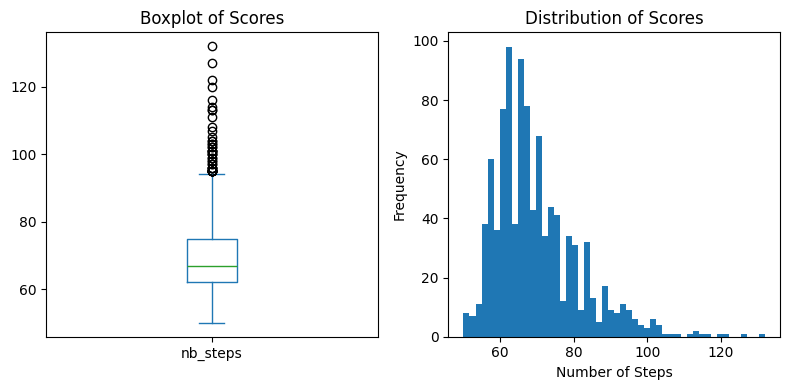

In [11]:
show_results(df_model_2_comm_2)
df_model_2_comm_2.to_csv('model_2_comm_1_and_comm_2.csv', index=False)

In [12]:
# Model large size (24x16) w. 12 robots (G:4 - Y:4 - R:4)

df_model_3_comm_2 = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_3_with_comm_2 = RobotMission(robot_type="With communication",
                      nb_green_robots=4,
                      nb_yellow_robots=4,
                      nb_red_robots=4,
                      nb_green_wastes=10,
                      nb_yellow_wastes=7,
                      nb_red_wastes=5,
                      width=24,
                      height=16)

avg_score, avg_terminated = evaluate_model(model_3_with_comm_2, N, max_steps, df_model_3_comm_2)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [03:01<00:00,  5.51it/s]

Average Score : 125.80 steps
Average termination of mission : 100.00%


Average nb_steps (Nb. steps to clean): 125.80
Maximum nb_steps (Nb. steps to clean): 270.00
Minimum nb_steps (Nb. steps to clean): 69.00
Percentage of terminated missions: 100.00 %
Average number of messages sent by comm_1: 133.53
Average number of messages sent by comm_2: 44.00


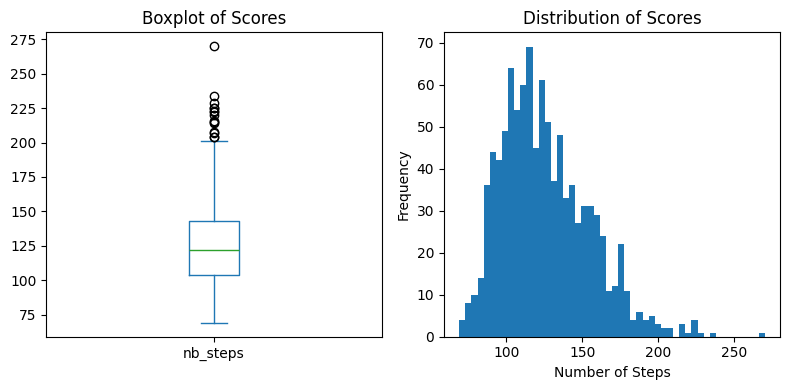

In [13]:
show_results(df_model_3_comm_2)
df_model_3_comm_2.to_csv('model_3_comm_1_and_comm_2.csv', index=False)

### Comparing the different results



In [15]:
import glob
import os

files = glob.glob('benchmarks/model_*.csv')   
dfs = []
for fp in files:
    df = pd.read_csv(fp)
    fname = os.path.basename(fp).replace('.csv','').split('_')
    model_num = fname[1]
    scenario = '_'.join(fname[2:])
    df['model'] = f'model_{model_num}'
    df['scenario'] = scenario
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)


In [21]:
summary = all_df.groupby(['model','scenario']).agg(
    avg_steps=('nb_steps','mean'),
    termination_rate=('terminated','mean'),
    avg_comm1=('nb_sent_msgs_comm_1','mean'),
    avg_comm2=('nb_sent_msgs_comm_2','mean')
).reset_index()
summary['termination_rate'] *= 100   

model_order    = ['model_1','model_2','model_3']
scenario_order = [
    'no_comm_no_drop',
    'no_comm_drop',
    'comm_1_only',
    'comm_1_and_comm_2'
]

summary['model']    = pd.Categorical(summary['model'],    categories=model_order,    ordered=True)
summary['scenario'] = pd.Categorical(summary['scenario'], categories=scenario_order, ordered=True)
summary = summary.sort_values(['model','scenario']).reset_index(drop=True)


summary



,model,scenario,avg_steps,termination_rate,avg_comm1,avg_comm2
0,model_1,no_comm_no_drop,440.432,61.2,0.000,0.0
1,model_1,no_comm_drop,115.259,100.0,0.000,0.0
2,model_1,comm_1_only,67.158,100.0,21.885,0.0
3,model_1,comm_1_and_comm_2,53.754,100.0,21.387,12.0
4,model_2,no_comm_no_drop,101.371,100.0,0.000,0.0
5,model_2,no_comm_drop,100.880,100.0,0.000,0.0
6,model_2,comm_1_only,99.412,100.0,0.000,0.0
7,model_2,comm_1_and_comm_2,69.895,100.0,0.000,6.0
8,model_3,no_comm_no_drop,895.087,16.3,0.000,0.0
9,model_3,no_comm_drop,596.139,80.8,0.000,0.0


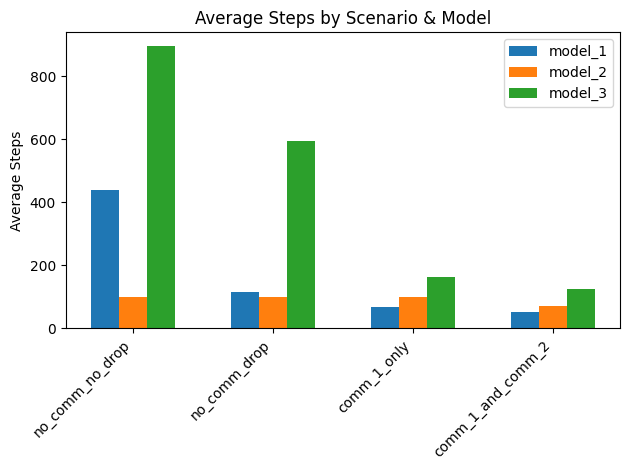

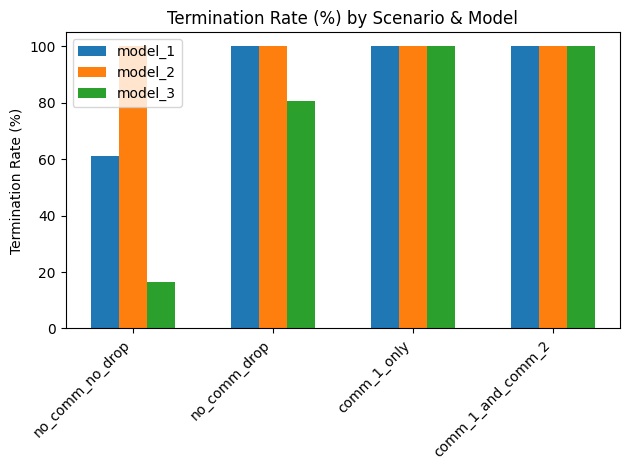

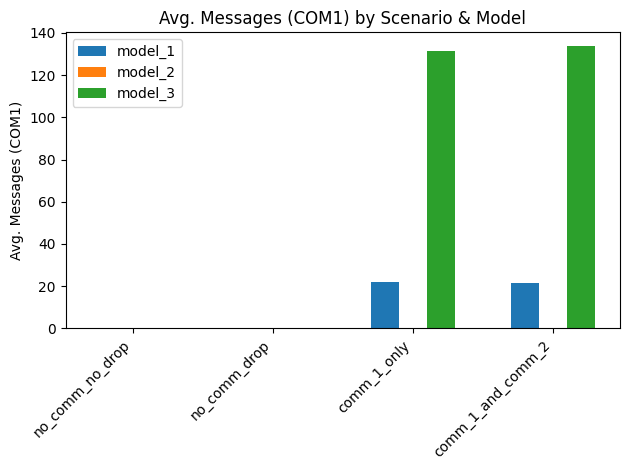

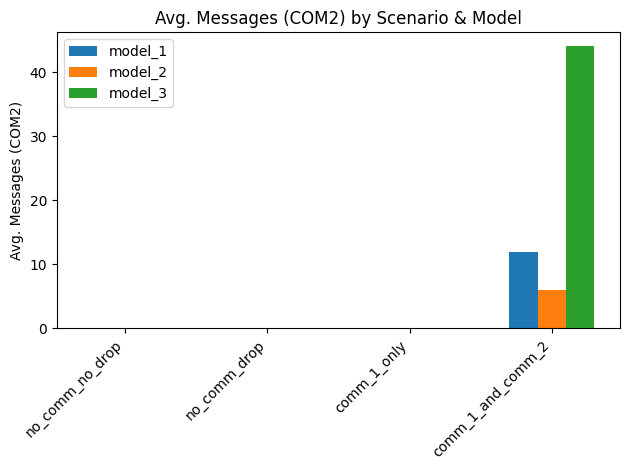

In [22]:
metrics = {
    'avg_steps': 'Average Steps',
    'termination_rate': 'Termination Rate (%)',
    'avg_comm1': 'Avg. Messages (COM1)',
    'avg_comm2': 'Avg. Messages (COM2)',
}

for metric, label in metrics.items():
    pivot = summary.pivot(index='scenario', columns='model', values=metric)
    x = range(len(pivot))
    width = 0.2

    fig, ax = plt.subplots()
    for i, model in enumerate(pivot.columns):
        ax.bar([pos + i*width for pos in x], pivot[model], width, label=model)

    ax.set_xticks([pos + width*(len(pivot.columns)-1)/2 for pos in x])
    ax.set_xticklabels(pivot.index, rotation=45, ha='right')
    ax.set_ylabel(label)
    ax.set_title(f"{label} by Scenario & Model")
    ax.legend()
    plt.tight_layout()
    plt.show()
